# EE 446 TinyML — Model Pruning with Quantization  


## 1. Environment Setup


In [2]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: C:\Users\shabb\anaconda3\python.exe
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt")).astype(np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(np.int32) - 1
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt")).astype(np.float32)
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(np.int32) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)

X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection

In [5]:
label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary

,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN


### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
92/92 [==============================] - 2s 9ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0769 - accuracy: 0.9696 - val_loss: 0.2337 - val_accuracy: 0.9252
Epoch 7/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0735 - accuracy: 0.9731 - val_loss: 0.1396 - val_accuracy: 0.9449
Epoch 8/40
92/92 [==

### Training Curves

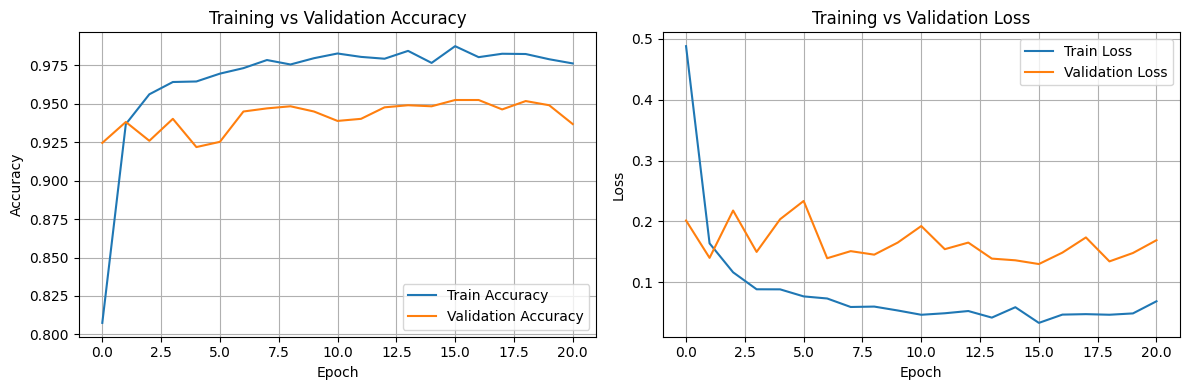

In [8]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["accuracy"], label="Train Accuracy")
axes[0].plot(history_df["val_accuracy"], label="Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_df["loss"], label="Train Loss")
axes[1].plot(history_df["val_loss"], label="Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Training vs Validation Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Evaluate the Baseline Keras Model

Test Accuracy: 0.9332

                    precision    recall  f1-score   support

           WALKING     0.9208    0.9839    0.9513       496
  WALKING_UPSTAIRS     0.9630    0.8854    0.9226       471
WALKING_DOWNSTAIRS     0.9390    0.9524    0.9456       420
           SITTING     0.9313    0.8839    0.9070       491
          STANDING     0.8606    0.9398    0.8985       532
            LAYING     1.0000    0.9516    0.9752       537

          accuracy                         0.9332      2947
         macro avg     0.9358    0.9328    0.9334      2947
      weighted avg     0.9354    0.9332    0.9333      2947



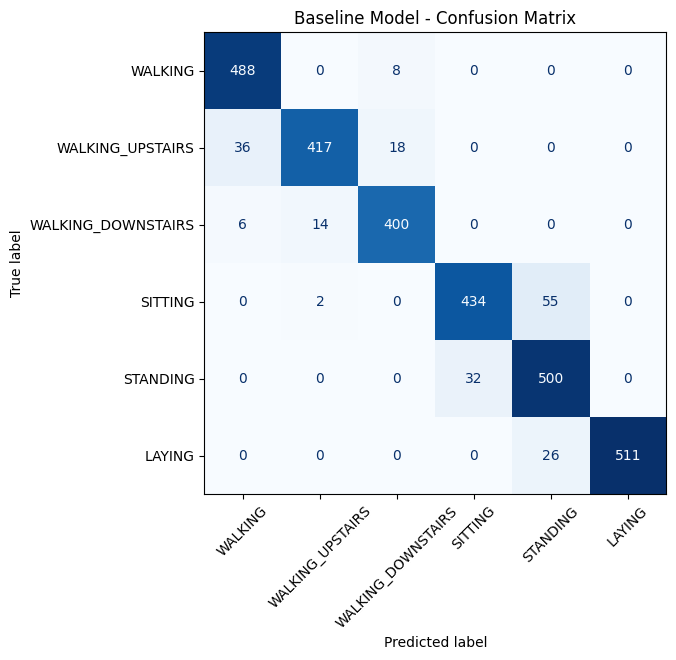

In [9]:
baseline_probs = baseline_model.predict(X_test, verbose=0)
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_test_acc = accuracy_score(y_test, baseline_preds)

print(f"Test Accuracy: {baseline_test_acc:.4f}\n")
print(classification_report(y_test, baseline_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Model - Confusion Matrix")
plt.show()

# Part I: Model Pruning with Sparsity


## 7. TensorFlow Lite Utilities

In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

## 8. Convert the Baseline Model to TensorFlow Lite

In [11]:
baseline_fp32_tflite = convert_to_tflite_fp32(baseline_model)
baseline_fp32_size_kb = save_binary_model(baseline_fp32_tflite, "baseline_fp32.tflite")
baseline_fp32_acc, baseline_fp32_preds = evaluate_tflite_model(baseline_fp32_tflite, X_test, y_test)

print(f"Baseline FP32 TFLite - Accuracy: {baseline_fp32_acc:.4f}, Size: {baseline_fp32_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpmvo7wo5p\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpmvo7wo5p\assets


Baseline FP32 TFLite - Accuracy: 0.9332, Size: 726.72 KB


## 9. Apply Magnitude-Based Pruning


In [12]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}

pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

pruning_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)

Epoch 1/12
92/92 [==============================] - 5s 10ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 1s 6ms/step - loss: 0.1663 - accuracy: 0.9367 - val_loss: 0.1592 - val_accuracy: 0.9293
Epoch 3/12
92/92 [==============================] - 1s 6ms/step - loss: 0.1311 - accuracy: 0.9498 - val_loss: 0.2181 - val_accuracy: 0.9279
Epoch 4/12
92/92 [==============================] - 1s 6ms/step - loss: 0.0917 - accuracy: 0.9691 - val_loss: 0.1643 - val_accuracy: 0.9320
Epoch 5/12
92/92 [==============================] - 1s 6ms/step - loss: 0.1390 - accuracy: 0.9452 - val_loss: 0.1457 - val_accuracy: 0.9368
Epoch 6/12
92/92 [==============================] - 1s 6ms/step - loss: 0.1372 - accuracy: 0.9527 - val_loss: 0.1634 - val_accuracy: 0.9347
Epoch 7/12
92/92 [==============================] - 1s 6ms/step - loss: 0.3049 - accuracy: 0.9262 - val_loss: 0.1661 - val_accuracy: 0.9388
Epoch 8/12
92/92 [=

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers


In [13]:
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

stripped_model = strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned with mask - Accuracy: {pruned_with_mask_acc:.4f}, Size: {pruned_with_mask_size_kb:.2f} KB")
print(f"Stripped sparse  - Accuracy: {stripped_sparse_acc:.4f}, Size: {stripped_sparse_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpsyy1z_hj\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpsyy1z_hj\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpcwrqdz_y\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpcwrqdz_y\assets


Pruned with mask - Accuracy: 0.9240, Size: 1454.18 KB
Stripped sparse  - Accuracy: 0.9240, Size: 196.23 KB


## 11. Part I Comparison: Accuracy and Model Size

In [14]:
part1_results = pd.DataFrame([
    ["Baseline", "FP32 TFLite", baseline_fp32_acc, baseline_fp32_size_kb],
    ["Pruned (with mask)", "FP32 TFLite", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse", "FP32 TFLite + Sparsity", stripped_sparse_acc, stripped_sparse_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part1_results

,Model,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32 TFLite,0.933152,726.718750
1,Pruned (with mask),FP32 TFLite,0.923990,1454.175781
2,Stripped Sparse,FP32 TFLite + Sparsity,0.923990,196.226562


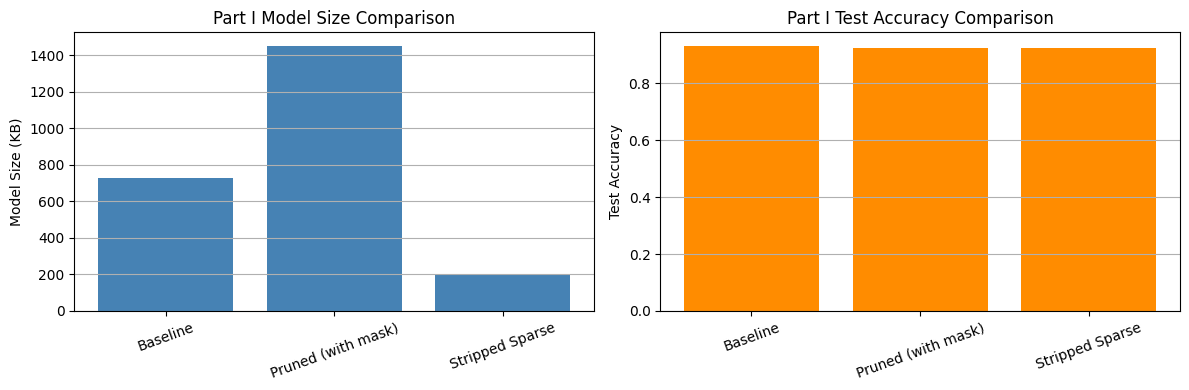

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(part1_results["Model"], part1_results["Model Size (KB)"], color="steelblue")
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part I Model Size Comparison")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y")

axes[1].bar(part1_results["Model"], part1_results["Test Accuracy"], color="darkorange")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Part I Test Accuracy Comparison")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model

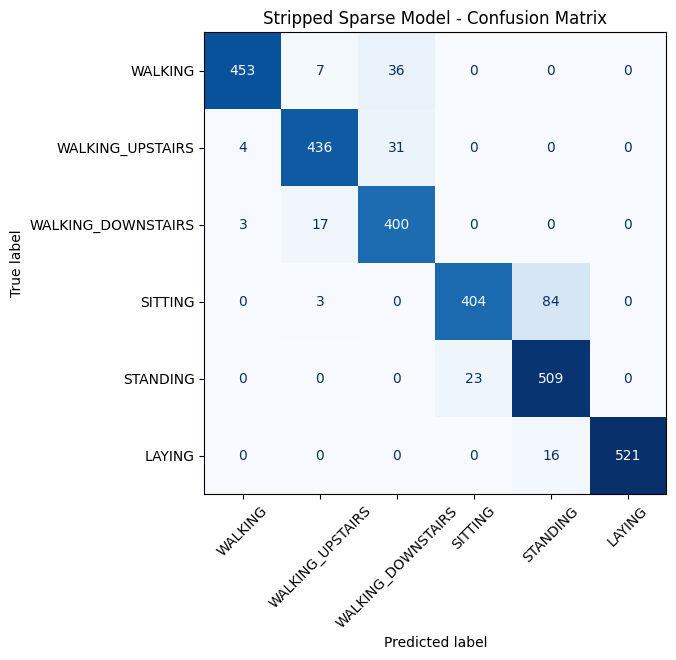

                    precision    recall  f1-score   support

           WALKING     0.9848    0.9133    0.9477       496
  WALKING_UPSTAIRS     0.9417    0.9257    0.9336       471
WALKING_DOWNSTAIRS     0.8565    0.9524    0.9019       420
           SITTING     0.9461    0.8228    0.8802       491
          STANDING     0.8358    0.9568    0.8922       532
            LAYING     1.0000    0.9702    0.9849       537

          accuracy                         0.9240      2947
         macro avg     0.9275    0.9235    0.9234      2947
      weighted avg     0.9291    0.9240    0.9244      2947



In [16]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse Model - Confusion Matrix")
plt.show()

print(classification_report(y_test, stripped_sparse_preds, target_names=class_names, digits=4))

# Part II: Model Pruning + Float16 Quantization

In [17]:
pruned_with_mask_float16_converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
pruned_with_mask_float16_converter.optimizations = [tf.lite.Optimize.DEFAULT]
pruned_with_mask_float16_converter.target_spec.supported_types = [tf.float16]
pruned_with_mask_float16_tflite = pruned_with_mask_float16_converter.convert()

pruned_with_mask_float16_size_kb = save_binary_model(
    pruned_with_mask_float16_tflite, "pruned_with_mask_float16.tflite"
)
pruned_with_mask_float16_acc, pruned_with_mask_float16_preds = evaluate_tflite_model(
    pruned_with_mask_float16_tflite, X_test, y_test
)

stripped_sparse_float16_converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
stripped_sparse_float16_converter.optimizations = [
    tf.lite.Optimize.DEFAULT,
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY
]
stripped_sparse_float16_converter.target_spec.supported_types = [tf.float16]
stripped_sparse_float16_tflite = stripped_sparse_float16_converter.convert()

stripped_sparse_float16_size_kb = save_binary_model(
    stripped_sparse_float16_tflite, "stripped_sparse_float16.tflite"
)
stripped_sparse_float16_acc, stripped_sparse_float16_preds = evaluate_tflite_model(
    stripped_sparse_float16_tflite, X_test, y_test
)

print(f"Pruned + Float16 (with mask) - Accuracy: {pruned_with_mask_float16_acc:.4f}, Size: {pruned_with_mask_float16_size_kb:.2f} KB")
print(f"Stripped Sparse + Float16    - Accuracy: {stripped_sparse_float16_acc:.4f}, Size: {stripped_sparse_float16_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmp51xk_g2z\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmp51xk_g2z\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpklym_2d_\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpklym_2d_\assets


Pruned + Float16 (with mask) - Accuracy: 0.9240, Size: 732.59 KB
Stripped Sparse + Float16    - Accuracy: 0.9240, Size: 130.47 KB


## 12. Part II Comparison: Accuracy and Model Size

In [18]:
part2_results = pd.DataFrame([
    ["Pruned (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Pruned (with mask)", "Float16", pruned_with_mask_float16_acc, pruned_with_mask_float16_size_kb],
    ["Stripped Sparse", "Float16 + Sparse", stripped_sparse_float16_acc, stripped_sparse_float16_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results

,Model,Format,Test Accuracy,Model Size (KB)
0,Pruned (with mask),FP32,0.92399,1454.175781
1,Stripped Sparse,FP32 + Sparse,0.92399,196.226562
2,Pruned (with mask),Float16,0.92399,732.585938
3,Stripped Sparse,Float16 + Sparse,0.92399,130.468750


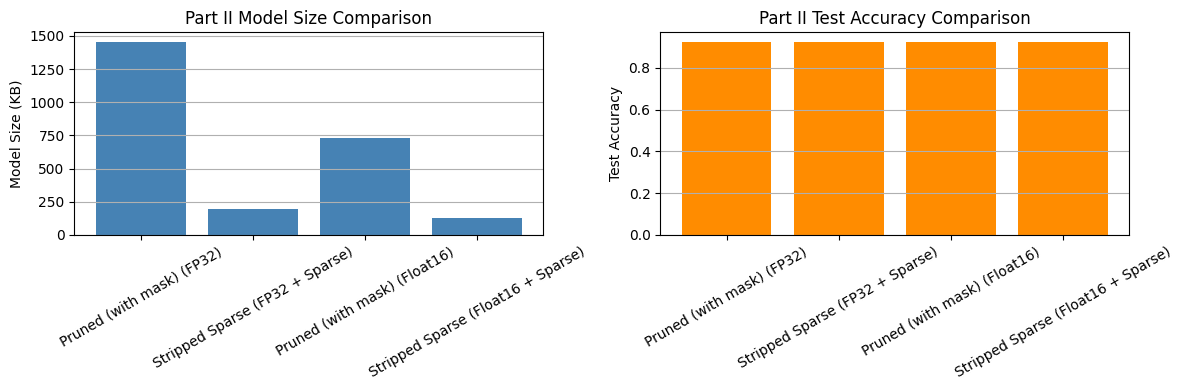

In [19]:
labels = part2_results["Model"] + " (" + part2_results["Format"] + ")"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, part2_results["Model Size (KB)"], color="steelblue")
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part II Model Size Comparison")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y")

axes[1].bar(labels, part2_results["Test Accuracy"], color="darkorange")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Part II Test Accuracy Comparison")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

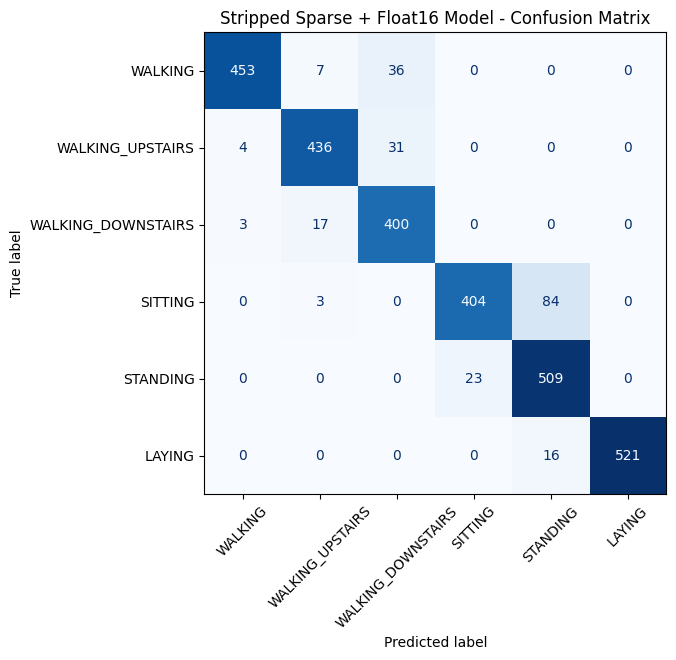

                    precision    recall  f1-score   support

           WALKING     0.9848    0.9133    0.9477       496
  WALKING_UPSTAIRS     0.9417    0.9257    0.9336       471
WALKING_DOWNSTAIRS     0.8565    0.9524    0.9019       420
           SITTING     0.9461    0.8228    0.8802       491
          STANDING     0.8358    0.9568    0.8922       532
            LAYING     1.0000    0.9702    0.9849       537

          accuracy                         0.9240      2947
         macro avg     0.9275    0.9235    0.9234      2947
      weighted avg     0.9291    0.9240    0.9244      2947



In [20]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_float16_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse + Float16 Model - Confusion Matrix")
plt.show()

print(classification_report(y_test, stripped_sparse_float16_preds, target_names=class_names, digits=4))

### Questions

**1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?**
No, the pruned model with the pruning wrappers still attached is usually about the same size as (or even slightly larger than) the FP32 baseline. The wrapper layers store both the original weight tensor and a mask tensor, and a standard FP32 conversion has no way to compress the zeroed-out weights, so the sparsity isn't reflected in file size yet.

**2. Why does strip_pruning(...) matter before export?**
strip_pruning removes the pruning-wrapper machinery and bakes the sparsity directly into ordinary dense layers, leaving a normal Keras model with many exact-zero weights. Only after that, combined with tf.lite.Optimize.EXPERIMENTAL_SPARSITY at conversion time, can the TFLite converter actually encode the sparse weight matrices compactly instead of storing every zero explicitly.

**3. Which model had the smallest file size in this notebook?**
The stripped sparse + float16 model, since it stacks two independent compression techniques: sparsity-aware encoding from pruning and half precision weights from float16 quantization.

**4. Did float16 quantization noticeably change the test accuracy?**
No, float16 quantization is expected to leave test accuracy nearly unchanged (within a fraction of a percentage point) relative to the FP32 counterpart, since it only reduces numeric precision rather than rounding to a small integer range like int8 does.

**5. If you were deploying this model on a resource-constrained device, which version would you choose and why?**
The stripped sparse + float16 model, it combines the smallest footprint in this notebook with accuracy close to the unpruned baseline, a good balance for a device that still supports float16 inference but has tight flash/RAM budgets.

